In [ ]:
!pip install gliner2
!pip install torch

In [2]:
"""
relation_extraction.py

Runs GLiNER2 relation extraction on the
American Institute of Physics Oral Histories Transcript collection.

Input:
- bib_interviewee_date_body.json

Output:
- gliner2_relations_START_END.json

The output consolidates identical:
    relation + head + tail

across all processed transcripts.
"""

from google.colab import drive

drive.mount("/content/drive")

import os
import re
import json

from collections import Counter
from bs4 import BeautifulSoup
from gliner2 import GLiNER2

import torch

BASE_DIR = "/content/drive/MyDrive/HDSSI_AIP"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "bib_interviewee_date_body.json"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "gliner2_relation_runs"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

#MODEL_NAME = "fastino/gliner2-base-v1"
MODEL_PATH = "/content/drive/MyDrive/HDSSI_AIP/gliner2-base-v1"


# Transcript subset.
#
# For testing:
# START = 0
# END = 10
#
# For all transcripts:
# START = 0
# END = None

"""
For last chunk:

START = 1700
END = None
"""

START = 1700
END = 1800 # exclusive

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    f"gliner2_relations_{START}_{END}.json"
)

# Approximate maximum characters per model input.
MAX_CHARS = 5000

# Repeated characters between consecutive chunks.
# This helps retain relations that cross a chunk boundary.
OVERLAP_CHARS = 200

# Save the consolidated output after this many transcripts.
SAVE_EVERY = 10

# Maximum number of example contexts retained for each
# consolidated relation triple. (not equal to total count)
MAX_EXAMPLES = 1

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
RELATION_SCHEMA = {
    "collaborated_with": {
        "description": (
            "Research collaboration between two named people who jointly "
            "conducted scientific research, experiments, projects, "
            "calculations, or publications."
        ),
        "threshold": 0.65
    },

    "supervised_by": {
        "description": (
            "Academic or research supervision where the source person was "
            "supervised, advised, or trained by the target named person."
        ),
        "threshold": 0.70
    },

    "worked_at": {
        "description": (
            "Employment or professional appointment where the source person "
            "worked at the target institution, university, laboratory, "
            "company, agency, or organization."
        ),
        "threshold": 0.70
    },

    "worked_on": {
        "description": (
            "Scientific participation where the source person worked on the "
            "target experiment, project, instrument, theory, facility, "
            "or research program."
        ),
        "threshold": 0.65
    },

    "supported_by": {
        "description": (
            "The source person received meaningful personal, administrative, "
            "intellectual, emotional, logistical, technical, or career support "
            "from the target named person."
        ),
        "threshold": 0.65
    },

    "assisted_by": {
        "description": (
            "The source person received concrete assistance with research, "
            "experiments, calculations, laboratory work, writing, technical "
            "work, or professional tasks from the target named person."
        ),
        "threshold": 0.65
    },

    "married_to": {
        "description": (
            "Marriage or spousal relationship between two named people, "
            "including wife, husband, spouse, or married."
        ),
        "threshold": 0.70
    },

    "parent_of": {
        "description": (
            "Family relationship where the source person is the parent, "
            "mother, or father of the target named person."
        ),
        "threshold": 0.75
    },

    "child_of": {
        "description": (
            "Family relationship where the source person is the child, "
            "son, or daughter of the target named parent."
        ),
        "threshold": 0.75
    },

    "sibling_of": {
        "description": (
            "Family relationship between two named siblings, including "
            "brothers and sisters."
        ),
        "threshold": 0.75
    }
}

In [26]:
# text helpers
def clean_html(html_text):
    """
    Convert the HTML transcript body to plain text while retaining
    paragraph and speaker-turn boundaries.
    """
    if not html_text:
        return ""

    soup = BeautifulSoup(html_text, "html.parser")

    block_tags = [
        "h1",
        "h2",
        "h3",
        "h4",
        "p",
        "div",
        "li",
        "blockquote"
    ]

    for tag in soup.find_all(block_tags):
        tag.insert_before("\n")
        tag.insert_after("\n")

    for tag in soup.find_all("br"):
        tag.replace_with("\n")

    text = soup.get_text(" ", strip=False)

    # Normalize spaces but preserve newlines.
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r" *\n *", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


def normalize_text(text):
    """
    Normalize whitespace for entity names, relation endpoints,
    and comparison keys.
    """
    if text is None:
        return ""

    return re.sub(r"\s+", " ", str(text)).strip()


def split_long_segment(segment, max_chars):
    """
    Split one long speaker turn or paragraph.

    The function prefers sentence boundaries but falls back to a
    fixed character boundary when necessary.
    """
    pieces = []
    remaining = segment.strip()

    while len(remaining) > max_chars:
        candidate = remaining[:max_chars]

        possible_breaks = [
            candidate.rfind(". "),
            candidate.rfind("? "),
            candidate.rfind("! "),
            candidate.rfind("; "),
            candidate.rfind(": "),
            candidate.rfind("\n")
        ]

        split_at = max(possible_breaks)

        # Do not create an extremely small first piece.
        if split_at < max_chars // 2:
            split_at = max_chars
        else:
            split_at += 1

        piece = remaining[:split_at].strip()

        if piece:
            pieces.append(piece)

        remaining = remaining[split_at:].strip()

    if remaining:
        pieces.append(remaining)

    return pieces


def create_overlapping_chunks(
    text,
    max_chars=2500,
    overlap_chars=400
):
    """
    Split a transcript into overlapping chunks.

    Speaker-turn and paragraph boundaries are preferred. The overlap
    helps retain relations whose evidence crosses a chunk boundary.
    """
    if not text:
        return []

    segments = [
        segment.strip()
        for segment in re.split(r"\n+", text)
        if segment.strip()
    ]

    expanded_segments = []

    for segment in segments:
        if len(segment) <= max_chars:
            expanded_segments.append(segment)
        else:
            expanded_segments.extend(
                split_long_segment(
                    segment,
                    max_chars
                )
            )

    chunks = []
    current_chunk = ""

    for segment in expanded_segments:
        if current_chunk:
            proposed_chunk = current_chunk + "\n" + segment
        else:
            proposed_chunk = segment

        if len(proposed_chunk) <= max_chars:
            current_chunk = proposed_chunk
            continue

        if current_chunk:
            chunks.append(current_chunk.strip())

        if overlap_chars > 0 and current_chunk:
            overlap = current_chunk[-overlap_chars:].strip()
            current_chunk = overlap + "\n" + segment
        else:
            current_chunk = segment

        # The overlap and new segment may still exceed the maximum.
        if len(current_chunk) > max_chars:
            smaller_chunks = split_long_segment(
                current_chunk,
                max_chars
            )

            if len(smaller_chunks) > 1:
                chunks.extend(smaller_chunks[:-1])

            current_chunk = smaller_chunks[-1]

    if current_chunk.strip():
        chunks.append(current_chunk.strip())

    return chunks

In [27]:
# relation parsing

def parse_relation_item(item):
    """
    Convert a GLiNER2 relation result into a consistent format.

    Supported input formats:

    Simple pair:
        ["Maury Tigner", "Robert Wilson"]

    Dictionary:
        {
            "head": {
                "text": "Maury Tigner",
                "confidence": 0.92,
                "start": 10,
                "end": 22
            },
            "tail": {
                "text": "Robert Wilson",
                "confidence": 0.90,
                "start": 35,
                "end": 48
            }
        }
    """

    if isinstance(item, (list, tuple)) and len(item) == 2:
        return {
            "head": normalize_text(item[0]),
            "tail": normalize_text(item[1]),
            "head_confidence": None,
            "tail_confidence": None
        }

    if isinstance(item, dict):
        head_data = item.get("head", {})
        tail_data = item.get("tail", {})

        if isinstance(head_data, str):
            head_data = {
                "text": head_data
            }

        if isinstance(tail_data, str):
            tail_data = {
                "text": tail_data
            }

        return {
            "head": normalize_text(
                head_data.get("text", "")
            ),
            "tail": normalize_text(
                tail_data.get("text", "")
            ),
            "head_confidence": head_data.get(
                "confidence"
            ),
            "tail_confidence": tail_data.get(
                "confidence"
            )
        }

    return None


def relation_key(relation_type, head, tail):
    """
    Create a case-insensitive key for one relation triple.
    """
    return (
        relation_type.strip().casefold(),
        head.strip().casefold(),
        tail.strip().casefold()
    )

In [28]:
# consolidated output helpers

def add_relation_to_consolidated(
    consolidated,
    relation_type,
    head,
    tail,
    bib,
    interviewee,
    interview_date,
    chunk_index,
    context,
    head_confidence=None,
    tail_confidence=None
):
    """
    Add one extracted relation to the consolidated dictionary.
    """
    key = relation_key(
        relation_type,
        head,
        tail
    )

    if key not in consolidated:
        consolidated[key] = {
            "relation": relation_type,
            "head": head,
            "tail": tail,
            "counts_by_transcript": Counter(),
            "examples": []
        }

    record = consolidated[key]

    record["counts_by_transcript"][bib] += 1

    if len(record["examples"]) < MAX_EXAMPLES:
        record["examples"].append({
            "field_bib_number": bib,
            "interviewee": interviewee,
            "interview_date": interview_date,
            "chunk_index": chunk_index,
            "head_confidence": head_confidence,
            "tail_confidence": tail_confidence,
            "context": context
        })


def format_consolidated_output(consolidated):
    """
    Convert Counters into normal dictionaries and calculate
    transcript-level summary fields.
    """
    output = []

    for record in consolidated.values():
        counts = dict(
            record["counts_by_transcript"]
        )

        formatted_record = {
            "relation": record["relation"],
            "head": record["head"],
            "tail": record["tail"],

            # Number of distinct transcripts containing this relation.
            "transcript_count": len(counts),

            # Number of extracted mentions across chunks/transcripts.
            "total_count": sum(counts.values()),

            "counts_by_transcript": counts,
            "examples": record["examples"]
        }

        output.append(formatted_record)

    # Rank first by breadth across the collection, then by total mentions.
    output.sort(
        key=lambda item: (
            item["transcript_count"],
            item["total_count"]
        ),
        reverse=True
    )

    return output


def save_consolidated_output(consolidated, output_path):
    """
    Format and save the consolidated relation records.
    """
    formatted_output = format_consolidated_output(
        consolidated
    )

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(
            formatted_output,
            f,
            indent=2,
            ensure_ascii=False
        )

    return formatted_output

In [29]:
# validate paths

if not os.path.exists(BASE_DIR):
    raise FileNotFoundError(
        f"BASE_DIR does not exist:\n{BASE_DIR}\n\n"
        "Mount Google Drive at /content/drive and check the "
        "folder name under /content/drive/MyDrive."
    )

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(
        f"Input file does not exist:\n{INPUT_FILE}"
    )


# load GLINER2

"""
if MODEL_NAME == "your-model-name":
    raise ValueError(
        "Replace MODEL_NAME = 'your-model-name' with the actual "
        "GLiNER2 relation-extraction model name before running."
    )
"""

print("Loading GLiNER2 model...")
# print("Model:", MODEL_NAME)
if not os.path.isdir(MODEL_PATH):
    raise FileNotFoundError(
        f"Model folder not found:\n{MODEL_PATH}"
    )

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

extractor = GLiNER2.from_pretrained(
    MODEL_PATH,
    map_location = "cuda",
    local_files_only=True
)

schema = extractor.create_schema().relations(
    RELATION_SCHEMA
)

print("Model and relation schema loaded.")
print(f"Relation types: {len(RELATION_SCHEMA)}")


# load transcripts

print("\nLoading transcripts...")

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    transcripts = json.load(f)

if not isinstance(transcripts, list):
    raise ValueError(
        "Expected the input JSON to contain a list of transcript objects."
    )

if END is None:
    selected_transcripts = transcripts[START:]
else:
    selected_transcripts = transcripts[START:END]

print(f"Total transcripts in input: {len(transcripts)}")
print(f"Selected transcripts: {len(selected_transcripts)}")
print(f"Slice: START={START}, END={END}")

[transformers] You are using a model of type `extractor` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading GLiNER2 model...
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-base
Counting layer     : count_lstm_v2
Token pooling      : first
Model and relation schema loaded.
Relation types: 10

Loading transcripts...
Total transcripts in input: 1754
Selected transcripts: 54
Slice: START=1700, END=1800


In [30]:
def get_relation_context(
    chunk_text,
    head,
    tail,
    context_chars=250
):
    """
    Return a shortened excerpt around the relation endpoints.
    """
    text_lower = chunk_text.casefold()

    head_pos = text_lower.find(head.casefold())
    tail_pos = text_lower.find(tail.casefold())

    positions = [
        pos for pos in [head_pos, tail_pos]
        if pos != -1
    ]

    if not positions:
        return chunk_text[:context_chars * 2].strip()

    start_pos = min(positions)
    end_pos = max(
        head_pos + len(head) if head_pos != -1 else start_pos,
        tail_pos + len(tail) if tail_pos != -1 else start_pos
    )

    excerpt_start = max(0, start_pos - context_chars)
    excerpt_end = min(
        len(chunk_text),
        end_pos + context_chars
    )

    excerpt = chunk_text[
        excerpt_start:excerpt_end
    ].strip()

    if excerpt_start > 0:
        excerpt = "..." + excerpt

    if excerpt_end < len(chunk_text):
        excerpt = excerpt + "..."

    return excerpt

In [31]:
# run relation extraction

consolidated = {}

for transcript_index, transcript in enumerate(
    selected_transcripts,
    start=1
):
    bib = normalize_text(
        transcript.get("field_bib_number", "")
    )

    interviewee = normalize_text(
        transcript.get("interviewee", "")
    )

    interview_date = normalize_text(
        transcript.get("interview_date", "")
    )

    body = transcript.get("body", "")

    if not bib:
        bib = f"missing_bib_{START + transcript_index - 1}"

    clean_text = clean_html(body)

    chunks = create_overlapping_chunks(
        clean_text,
        max_chars=MAX_CHARS,
        overlap_chars=OVERLAP_CHARS
    )

    print(
        f"Processing {transcript_index}/"
        f"{len(selected_transcripts)}: "
        f"bib {bib} | "
        f"{len(chunks)} chunks",
        flush=True
    )

    # Helps avoid duplicate copies of the same exact triple
    # returned more than once from a single chunk.
    for chunk_index, chunk_text in enumerate(chunks):
        try:
            result = extractor.extract(
                chunk_text,
                schema
            )

        except Exception as error:
            print(
                f"  Error in bib {bib}, chunk {chunk_index}: "
                f"{error}",
                flush=True
            )
            continue

        relation_results = result.get(
            "relation_extraction",
            {}
        )

        seen_in_chunk = set()

        for relation_type in RELATION_SCHEMA:
            extracted_items = relation_results.get(
                relation_type,
                []
            )

            for item in extracted_items:
                parsed = parse_relation_item(item)

                if parsed is None:
                    continue

                head = parsed["head"]
                tail = parsed["tail"]

                if not head or not tail:
                    continue

                # Skip self-relations such as:
                # Robert Wilson --collaborated_with--> Robert Wilson
                if head.casefold() == tail.casefold():
                    continue

                current_key = relation_key(
                    relation_type,
                    head,
                    tail
                )

                # Prevent the same triple from being counted twice
                # if the model repeats it inside one chunk.
                if current_key in seen_in_chunk:
                    continue

                seen_in_chunk.add(current_key)

                add_relation_to_consolidated(
                    consolidated=consolidated,
                    relation_type=relation_type,
                    head=head,
                    tail=tail,
                    bib=bib,
                    interviewee=interviewee,
                    interview_date=interview_date,
                    chunk_index=chunk_index,
                    context=get_relation_context(
                        chunk_text,
                        head,
                        tail,
                        context_chars=250
                    ),
                    head_confidence=parsed[
                        "head_confidence"
                    ],
                    tail_confidence=parsed[
                        "tail_confidence"
                    ]
                )

    # Save periodically so progress is not lost if the session stops.
    if transcript_index % SAVE_EVERY == 0:
        current_output = save_consolidated_output(
            consolidated,
            OUTPUT_FILE
        )

        print(
            f"  Saved progress: "
            f"{len(current_output)} unique relation triples",
            flush=True
        )

Processing 1/54: bib 4490 | 16 chunks
Processing 2/54: bib 31208 | 33 chunks
Processing 3/54: bib 31207 | 7 chunks
Processing 4/54: bib 32155 | 12 chunks
Processing 5/54: bib 35672 | 15 chunks
Processing 6/54: bib 5899 | 6 chunks
Processing 7/54: bib 33891 | 41 chunks
Processing 8/54: bib 35131-2 | 20 chunks
Processing 9/54: bib 35131-1 | 22 chunks
Processing 10/54: bib 4488 | 6 chunks
  Saved progress: 341 unique relation triples
Processing 11/54: bib 24312-4 | 18 chunks
Processing 12/54: bib 24312-3 | 15 chunks
Processing 13/54: bib 24312-2 | 11 chunks
Processing 14/54: bib 24312-1 | 68 chunks
Processing 15/54: bib 23362-4 | 21 chunks
Processing 16/54: bib 23362-3 | 19 chunks
Processing 17/54: bib 23362-2 | 21 chunks
Processing 18/54: bib 23362-1 | 29 chunks
Processing 19/54: bib 30430 | 39 chunks
Processing 20/54: bib 25651-2 | 23 chunks
  Saved progress: 863 unique relation triples
Processing 21/54: bib 25651-1 | 6 chunks
Processing 22/54: bib 30428 | 38 chunks
Processing 23/54: bi

In [32]:
# final save

final_output = save_consolidated_output(
    consolidated,
    OUTPUT_FILE
)


# summary

print("\nRelation extraction complete.")

print(
    f"Processed transcripts: "
    f"{len(selected_transcripts)}"
)

print(
    f"Unique consolidated relation triples: "
    f"{len(final_output)}"
)

print(
    f"Output file:\n{OUTPUT_FILE}"
)


print("\nTop consolidated relations:")

for item in final_output[:25]:
    print(
        f"{item['head']} "
        f"--{item['relation']}--> "
        f"{item['tail']} "
        f"| transcripts: {item['transcript_count']} "
        f"| mentions: {item['total_count']}"
    )


Relation extraction complete.
Processed transcripts: 54
Unique consolidated relation triples: 2474
Output file:
/content/drive/MyDrive/HDSSI_AIP/gliner2_relation_runs/gliner2_relations_1700_1800.json

Top consolidated relations:
Anderson --worked_at--> Bell Labs | transcripts: 5 | mentions: 10
Anderson --worked_on--> thesis | transcripts: 4 | mentions: 4
Amaldi --collaborated_with--> Fermi | transcripts: 3 | mentions: 7
Anderson --worked_on--> superconductivity | transcripts: 3 | mentions: 4
mother --parent_of--> Aitken | transcripts: 3 | mentions: 4
John Rowell --worked_at--> Bell Labs | transcripts: 3 | mentions: 3
Anderson --worked_at--> Harvard | transcripts: 3 | mentions: 3
DeVorkin --parent_of--> Aitken | transcripts: 2 | mentions: 7
Alpher --collaborated_with--> Gamow | transcripts: 2 | mentions: 6
Aitken --supervised_by--> Doel | transcripts: 2 | mentions: 5
Aitken --supported_by--> mother | transcripts: 2 | mentions: 5
Anderson --worked_at--> Columbia | transcripts: 2 | menti

In [33]:
# ============================================================
# VERIFY OUTPUT JSON
# ============================================================

print("\nVerifying output JSON...")

try:
    with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
        verified_output = json.load(f)

    if not isinstance(verified_output, list):
        raise ValueError(
            "Expected the output JSON to contain a list of relation records."
        )

    print("✓ JSON is valid.")
    print(f"✓ Total relation records: {len(verified_output)}")

except json.JSONDecodeError as error:
    print(f"✗ Invalid JSON: {error}")

except Exception as error:
    print(f"✗ Verification failed: {error}")


Verifying output JSON...
✓ JSON is valid.
✓ Total relation records: 2474


In [4]:
# consolidate all GLiNER2 relation batch JSON files
#
# Expected input filenames:
# gliner2_relation_START_END.json
#
# Output:
# gliner2_relations_consolidated.json

import glob
from collections import defaultdict

BASE_DIR = "/content/drive/MyDrive/HDSSI_AIP/gliner2_relation_runs"

INPUT_PATTERN = os.path.join(
    BASE_DIR,
    "gliner2_relations_*.json"
)

OUTPUT_FILE = os.path.join(
    BASE_DIR,
    "gliner2_relations_consolidated.json"
)


# Find all batch output files
input_files = sorted(glob.glob(INPUT_PATTERN))

# Avoid accidentally reading the consolidated output if its name
# happens to match the input pattern.
input_files = [
    path for path in input_files
    if os.path.abspath(path) != os.path.abspath(OUTPUT_FILE)
]

if not input_files:
    raise FileNotFoundError(
        f"No GLiNER2 relation batch files found matching:\n"
        f"{INPUT_PATTERN}"
    )

print(f"Found {len(input_files)} batch files.")

for path in input_files:
    print(" -", os.path.basename(path))


# Stores one merged record for each unique:
# relation + head + tail
merged = {}


for file_index, input_file in enumerate(input_files, start=1):
    print(
        f"\nReading {file_index}/{len(input_files)}: "
        f"{os.path.basename(input_file)}"
    )

    with open(input_file, "r", encoding="utf-8") as f:
        batch_data = json.load(f)

    # Support either:
    # 1. a direct list of relation records
    # 2. {"relations": [...]}
    if isinstance(batch_data, dict):
        if "relations" not in batch_data:
            raise ValueError(
                f"Expected a 'relations' key in:\n{input_file}"
            )

        batch_relations = batch_data["relations"]

    elif isinstance(batch_data, list):
        batch_relations = batch_data

    else:
        raise ValueError(
            f"Expected a list or dictionary in:\n{input_file}"
        )

    if not isinstance(batch_relations, list):
        raise ValueError(
            f"Expected relation data to be a list in:\n{input_file}"
        )

    for record in batch_relations:
        if not isinstance(record, dict):
            continue

        relation = str(record.get("relation", "")).strip()
        head = str(record.get("head", "")).strip()
        tail = str(record.get("tail", "")).strip()

        if not relation or not head or not tail:
            continue

        # Case-sensitive key. Use .casefold() here if you want
        # capitalization differences to count as duplicates.
        key = (
            relation,
            head,
            tail,
        )

        total_count = record.get("total_count", 0)

        try:
            total_count = int(total_count)
        except (TypeError, ValueError):
            total_count = 0

        counts_by_transcript = record.get(
            "counts_by_transcript",
            {}
        )

        if not isinstance(counts_by_transcript, dict):
            counts_by_transcript = {}

        examples = record.get("examples", [])

        if not isinstance(examples, list):
            examples = []

        # Keep only one example for each merged relation.
        first_example = examples[0] if examples else None

        if key not in merged:
            merged[key] = {
                "relation": relation,
                "head": head,
                "tail": tail,
                "total_count": 0,
                "counts_by_transcript": defaultdict(int),
                "example": first_example,
            }

        merged_record = merged[key]

        merged_record["total_count"] += total_count

        for transcript_id, count in counts_by_transcript.items():
            try:
                count = int(count)
            except (TypeError, ValueError):
                count = 0

            merged_record["counts_by_transcript"][
                str(transcript_id)
            ] += count

        # If the first batch did not contain an example, use the
        # first available example from a later batch.
        if (
            merged_record["example"] is None
            and first_example is not None
        ):
            merged_record["example"] = first_example


# Convert merged records into JSON-serializable dictionaries.
consolidated_relations = []

for merged_record in merged.values():
    counts_by_transcript = dict(
        sorted(
            merged_record["counts_by_transcript"].items(),
            key=lambda item: item[0],
        )
    )

    # Recalculate transcript_count from the unique transcript IDs
    # represented across all batch files.
    transcript_count = len(counts_by_transcript)

    example = merged_record["example"]

    consolidated_relations.append(
        {
            "relation": merged_record["relation"],
            "head": merged_record["head"],
            "tail": merged_record["tail"],
            "transcript_count": transcript_count,
            "total_count": merged_record["total_count"],
            "counts_by_transcript": counts_by_transcript,
            # Keep exactly one example at most.
            "examples": [example] if example is not None else [],
        }
    )


# Sort from most frequent to least frequent.
# Alphabetical tie-breakers make output ordering reproducible.
consolidated_relations.sort(
    key=lambda record: (
        -record["total_count"],
        -record["transcript_count"],
        record["relation"].casefold(),
        record["head"].casefold(),
        record["tail"].casefold(),
    )
)


with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(
        consolidated_relations,
        f,
        ensure_ascii=False,
        indent=2,
    )


# Verify that the saved output is valid JSON.
with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
    verified_output = json.load(f)


print("\nConsolidation complete.")
print(f"Batch files combined: {len(input_files)}")
print(f"Unique relations: {len(verified_output)}")
print(f"Output file: {OUTPUT_FILE}")
print("Output JSON is valid.")

Found 18 batch files.
 - gliner2_relations_0_100.json
 - gliner2_relations_1000_1100.json
 - gliner2_relations_100_200.json
 - gliner2_relations_1100_1200.json
 - gliner2_relations_1200_1300.json
 - gliner2_relations_1300_1400.json
 - gliner2_relations_1400_1500.json
 - gliner2_relations_1500_1600.json
 - gliner2_relations_1600_1700.json
 - gliner2_relations_1700_1800.json
 - gliner2_relations_200_300.json
 - gliner2_relations_300_400.json
 - gliner2_relations_400_500.json
 - gliner2_relations_500_600.json
 - gliner2_relations_600_700.json
 - gliner2_relations_700_800.json
 - gliner2_relations_800_900.json
 - gliner2_relations_900_1000.json

Reading 1/18: gliner2_relations_0_100.json

Reading 2/18: gliner2_relations_1000_1100.json

Reading 3/18: gliner2_relations_100_200.json

Reading 4/18: gliner2_relations_1100_1200.json

Reading 5/18: gliner2_relations_1200_1300.json

Reading 6/18: gliner2_relations_1300_1400.json

Reading 7/18: gliner2_relations_1400_1500.json

Reading 8/18: gliner

In [5]:
NUM_TO_SHOW = 5

with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
    relations = json.load(f)

print(f"Loaded {len(relations)} relations.\n")

for i, relation in enumerate(relations[:NUM_TO_SHOW], start=1):
    print("=" * 80)
    print(f"Relation #{i}")
    print(json.dumps(relation, indent=2, ensure_ascii=False))
    print()

Loaded 72692 relations.

Relation #1
{
  "relation": "parent_of",
  "head": "Aaserud",
  "tail": "JASON",
  "transcript_count": 33,
  "total_count": 114,
  "counts_by_transcript": {
    "24321": 1,
    "25492": 9,
    "28394": 6,
    "31110": 1,
    "31393": 6,
    "33299": 3,
    "33455": 3,
    "33688": 3,
    "35154": 6,
    "4501": 3,
    "4578": 3,
    "4585": 8,
    "4630": 1,
    "4699": 3,
    "4704-1": 1,
    "4742": 1,
    "4750": 6,
    "4790": 6,
    "48122": 1,
    "4918": 1,
    "4919": 10,
    "4939": 2,
    "4990": 2,
    "4992": 2,
    "5050": 2,
    "5053": 3,
    "5063-1": 2,
    "5063-3": 5,
    "5075": 1,
    "5094": 3,
    "5146": 3,
    "5195": 5,
    "5196": 2
  },
  "examples": [
    {
      "field_bib_number": "48122",
      "interviewee": "Finn Aaserud",
      "interview_date": "Thu, 09/21/2023 - 12:00",
      "chunk_index": 5,
      "head_confidence": null,
      "tail_confidence": null,
      "context": "ace. So, I was able to look at the latter, I went thr

In [42]:
print(OUTPUT_FILE)

/content/drive/MyDrive/HDSSI_AIP/gliner2_relation_runs/gliner2_relations_consolidated.json


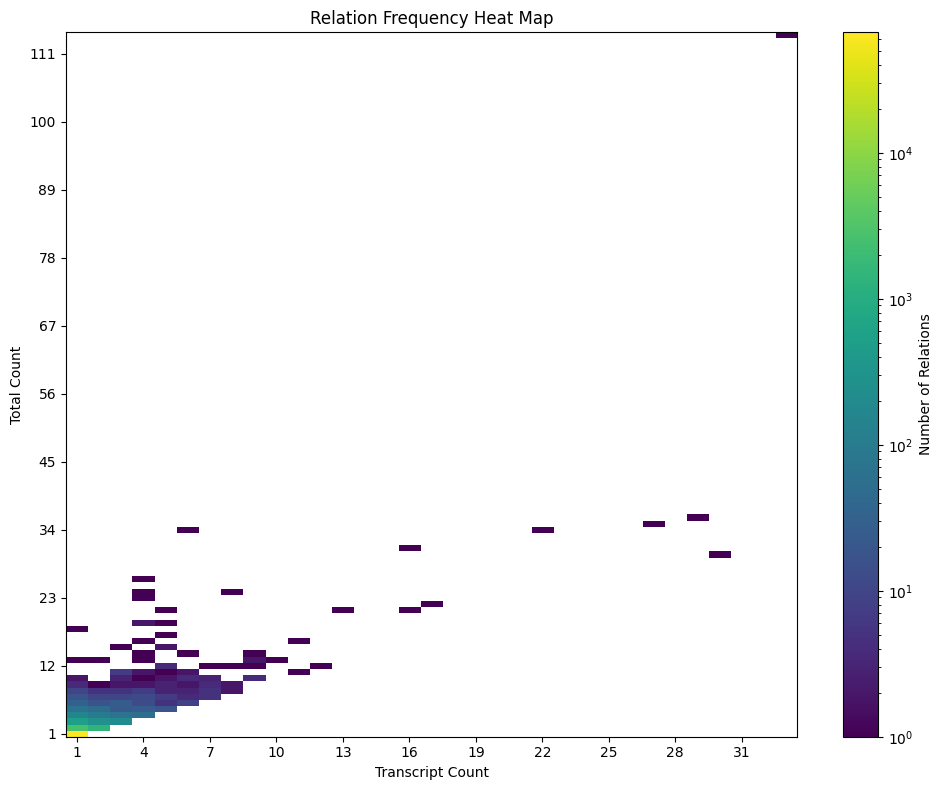

Unique (transcript_count, total_count) pairs: 92
Total relations: 72692


In [11]:
# Heat map of unique (transcript_count, total_count) pairs

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from collections import Counter

with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
    relations = json.load(f)

# Count the number of relations at each (transcript_count, total_count)
pair_counts = Counter(
    (
        r["transcript_count"],
        r["total_count"]
    )
    for r in relations
)

# Determine matrix size
max_x = max(x for x, _ in pair_counts.keys())
max_y = max(y for _, y in pair_counts.keys())

# Create matrix (rows = total_count, cols = transcript_count)
heatmap = np.zeros((max_y, max_x), dtype=int)

for (x, y), count in pair_counts.items():
    heatmap[y - 1, x - 1] = count

plt.figure(figsize=(10, 8))

im = plt.imshow(
    heatmap,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    norm=LogNorm(vmin=1),
    cmap="viridis"
)

cbar = plt.colorbar(im)
cbar.set_label("Number of Relations")

plt.title("Relation Frequency Heat Map")
plt.xlabel("Transcript Count")
plt.ylabel("Total Count")

# Show integer tick marks
plt.xticks(
    np.arange(0, max_x, max(1, max_x // 10)),
    np.arange(1, max_x + 1, max(1, max_x // 10))
)

plt.yticks(
    np.arange(0, max_y, max(1, max_y // 10)),
    np.arange(1, max_y + 1, max(1, max_y // 10))
)

plt.tight_layout()
plt.show()

print(f"Unique (transcript_count, total_count) pairs: {len(pair_counts)}")
print(f"Total relations: {len(relations)}")

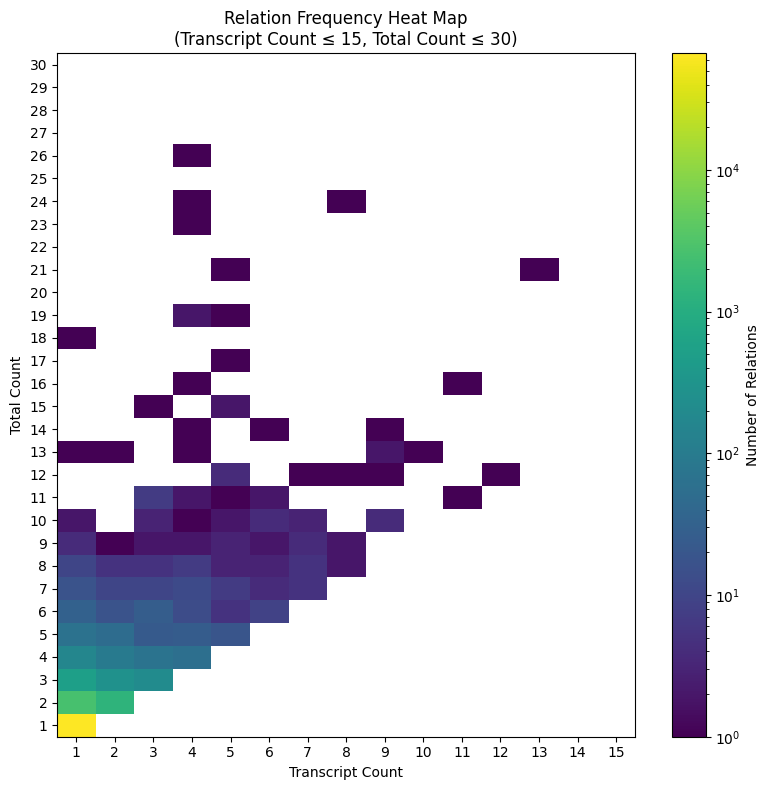

Relations shown: 72,683
Unique coordinate pairs shown: 83


In [12]:
# Zoomed-in heat map:
# transcript_count <= 15
# total_count <= 30

MAX_TRANSCRIPT_COUNT = 15
MAX_TOTAL_COUNT = 30

with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
    relations = json.load(f)

# Count occurrences of each (transcript_count, total_count) pair
pair_counts = Counter(
    (
        r["transcript_count"],
        r["total_count"]
    )
    for r in relations
)

# Create heatmap matrix
heatmap = np.zeros(
    (MAX_TOTAL_COUNT, MAX_TRANSCRIPT_COUNT),
    dtype=int
)

for (transcript_count, total_count), count in pair_counts.items():
    if (
        transcript_count <= MAX_TRANSCRIPT_COUNT
        and total_count <= MAX_TOTAL_COUNT
    ):
        heatmap[
            total_count - 1,
            transcript_count - 1
        ] = count

plt.figure(figsize=(8, 8))

im = plt.imshow(
    heatmap,
    origin="lower",
    interpolation="nearest",
    aspect="auto",
    cmap="viridis",
    norm=LogNorm(vmin=1)
)

cbar = plt.colorbar(im)
cbar.set_label("Number of Relations")

plt.xticks(
    np.arange(MAX_TRANSCRIPT_COUNT),
    np.arange(1, MAX_TRANSCRIPT_COUNT + 1)
)

plt.yticks(
    np.arange(MAX_TOTAL_COUNT),
    np.arange(1, MAX_TOTAL_COUNT + 1)
)

plt.xlabel("Transcript Count")
plt.ylabel("Total Count")
plt.title(
    "Relation Frequency Heat Map\n"
    "(Transcript Count ≤ 15, Total Count ≤ 30)"
)

plt.grid(False)
plt.tight_layout()
plt.show()

print(f"Relations shown: {heatmap.sum():,}")
print(f"Unique coordinate pairs shown: {(heatmap > 0).sum()}")

In [13]:
print(72692-72683)

9


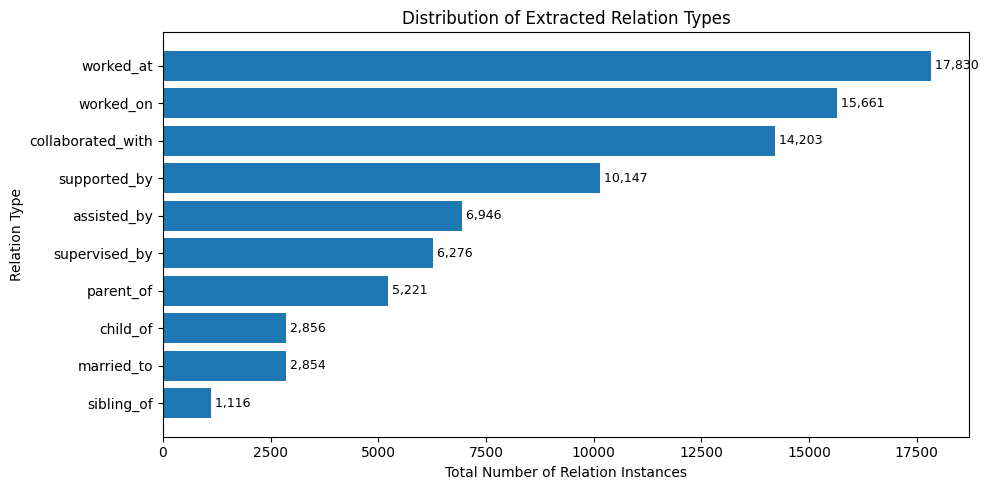

Unique relation types: 10


In [14]:
# Distribution of relation types
# (ranked by total_count)

TOP_K = None      # Set to an integer (e.g., 20) to show only the top K

with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
    relations = json.load(f)

relation_counts = Counter()

for relation in relations:
    relation_type = relation["relation"]

    relation_counts[relation_type] += relation["total_count"]

sorted_relations = relation_counts.most_common()

if TOP_K is not None:
    sorted_relations = sorted_relations[:TOP_K]

labels = [r[0] for r in sorted_relations]
counts = [r[1] for r in sorted_relations]

plt.figure(figsize=(10, max(5, len(labels) * 0.4)))

bars = plt.barh(labels, counts)

plt.xlabel("Total Number of Relation Instances")
plt.ylabel("Relation Type")
plt.title("Distribution of Extracted Relation Types")

plt.gca().invert_yaxis()

# Add count labels to bars
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {count:,}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

print(f"Unique relation types: {len(relation_counts)}")

In [34]:
# Generate a relation network for the top X entities
#
# Nodes = entities
# Edges = extracted relations
# Node size = ranking score
# Edge color = relation type
# Edge width = total relation frequency
#
# RANK_BY options:
# - "frequency": highest summed total_count
# - "connections": most unique neighboring entities

import networkx as nx
from matplotlib.lines import Line2D
from collections import Counter, defaultdict


TOP_X = 20

# Choose either:
# "frequency" or "connections"
RANK_BY = "frequency"

# True:
# Only include relations where both entities are in the top X.
#
# False (takes long time):
# Include relations where at least one entity is in the top X.
REQUIRE_BOTH_ENTITIES_IN_TOP_X = True


with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
    relations = json.load(f)

In [35]:
# Calculate entity frequency and connectivity
entity_frequency = Counter()
entity_neighbors = defaultdict(set)

for record in relations:
    head = str(record.get("head", "")).strip()
    tail = str(record.get("tail", "")).strip()

    if not head or not tail:
        continue

    try:
        total_count = int(record.get("total_count", 0))
    except (TypeError, ValueError):
        total_count = 0

    # Count how many relation appearances each entity has.
    entity_frequency[head] += total_count
    entity_frequency[tail] += total_count

    # Track each entity's unique neighbors.
    if head != tail:
        entity_neighbors[head].add(tail)
        entity_neighbors[tail].add(head)


entity_connection_count = Counter({
    entity: len(neighbors)
    for entity, neighbors in entity_neighbors.items()
})


# select top entities
if RANK_BY == "frequency":
    ranking = entity_frequency
    metric_label = "entity appearances"

elif RANK_BY == "connections":
    ranking = entity_connection_count
    metric_label = "entity connections"

else:
    raise ValueError(
        "RANK_BY must be either 'frequency' or 'connections'."
    )


top_entities_with_scores = ranking.most_common(TOP_X)

top_entities = {
    entity
    for entity, _ in top_entities_with_scores
}


print(f"Top {TOP_X} entities ranked by {RANK_BY}:\n")

for rank, (entity, score) in enumerate(
    top_entities_with_scores,
    start=1
):
    print(
        f"{rank:>2}. {entity} | "
        f"{metric_label}={score:,} | "
        f"frequency={entity_frequency[entity]:,} | "
        f"unique connections="
        f"{entity_connection_count.get(entity, 0):,}"
    )

Top 20 entities ranked by frequency:

 1. DeVorkin | entity appearances=3,243 | frequency=3,243 | unique connections=1,559
 2. Zierler | entity appearances=1,562 | frequency=1,562 | unique connections=645
 3. father | entity appearances=1,455 | frequency=1,455 | unique connections=796
 4. JASON | entity appearances=882 | frequency=882 | unique connections=298
 5. Aaserud | entity appearances=833 | frequency=833 | unique connections=305
 6. Feynman | entity appearances=817 | frequency=817 | unique connections=371
 7. wife | entity appearances=776 | frequency=776 | unique connections=467
 8. Bohr | entity appearances=764 | frequency=764 | unique connections=279
 9. mother | entity appearances=604 | frequency=604 | unique connections=293
10. Harvard | entity appearances=585 | frequency=585 | unique connections=368
11. MIT | entity appearances=546 | frequency=546 | unique connections=361
12. Caltech | entity appearances=503 | frequency=503 | unique connections=308
13. Heisenberg | entity a

In [36]:
# build graph
graph = nx.MultiDiGraph()

for record in relations:
    head = str(record.get("head", "")).strip()
    tail = str(record.get("tail", "")).strip()
    relation_type = str(record.get("relation", "")).strip()

    if not head or not tail or not relation_type:
        continue

    if REQUIRE_BOTH_ENTITIES_IN_TOP_X:
        include_edge = (
            head in top_entities
            and tail in top_entities
        )
    else:
        include_edge = (
            head in top_entities
            or tail in top_entities
        )

    if not include_edge:
        continue

    try:
        total_count = int(record.get("total_count", 0))
    except (TypeError, ValueError):
        total_count = 0

    graph.add_edge(
        head,
        tail,
        relation=relation_type,
        weight=max(total_count, 1)
    )


if graph.number_of_nodes() == 0:
    raise ValueError(
        "No graph nodes were created. Try setting "
        "REQUIRE_BOTH_ENTITIES_IN_TOP_X = False."
    )


# calculate node sizes
node_scores = [
    ranking.get(node, 1)
    for node in graph.nodes()
]

max_node_score = max(node_scores)

node_sizes = [
    1500 + 6000 * (score / max_node_score)
    for score in node_scores
]


# Create node labels with ranking metric
node_labels = {}

for node in graph.nodes():
    score = ranking.get(node, 0)

    node_labels[node] = (
        f"{node}\n"
        f"{metric_label}: {score:,}"
    )


# Assign one color to each relation type
relation_types = sorted({
    data["relation"]
    for _, _, data in graph.edges(data=True)
})

color_map = plt.get_cmap(
    "tab20",
    max(len(relation_types), 1)
)

relation_colors = {
    relation_type: color_map(index)
    for index, relation_type in enumerate(relation_types)
}


# Calculate global edge-width scaling
edge_weights = [
    data["weight"]
    for _, _, data in graph.edges(data=True)
]

max_edge_weight = max(edge_weights)

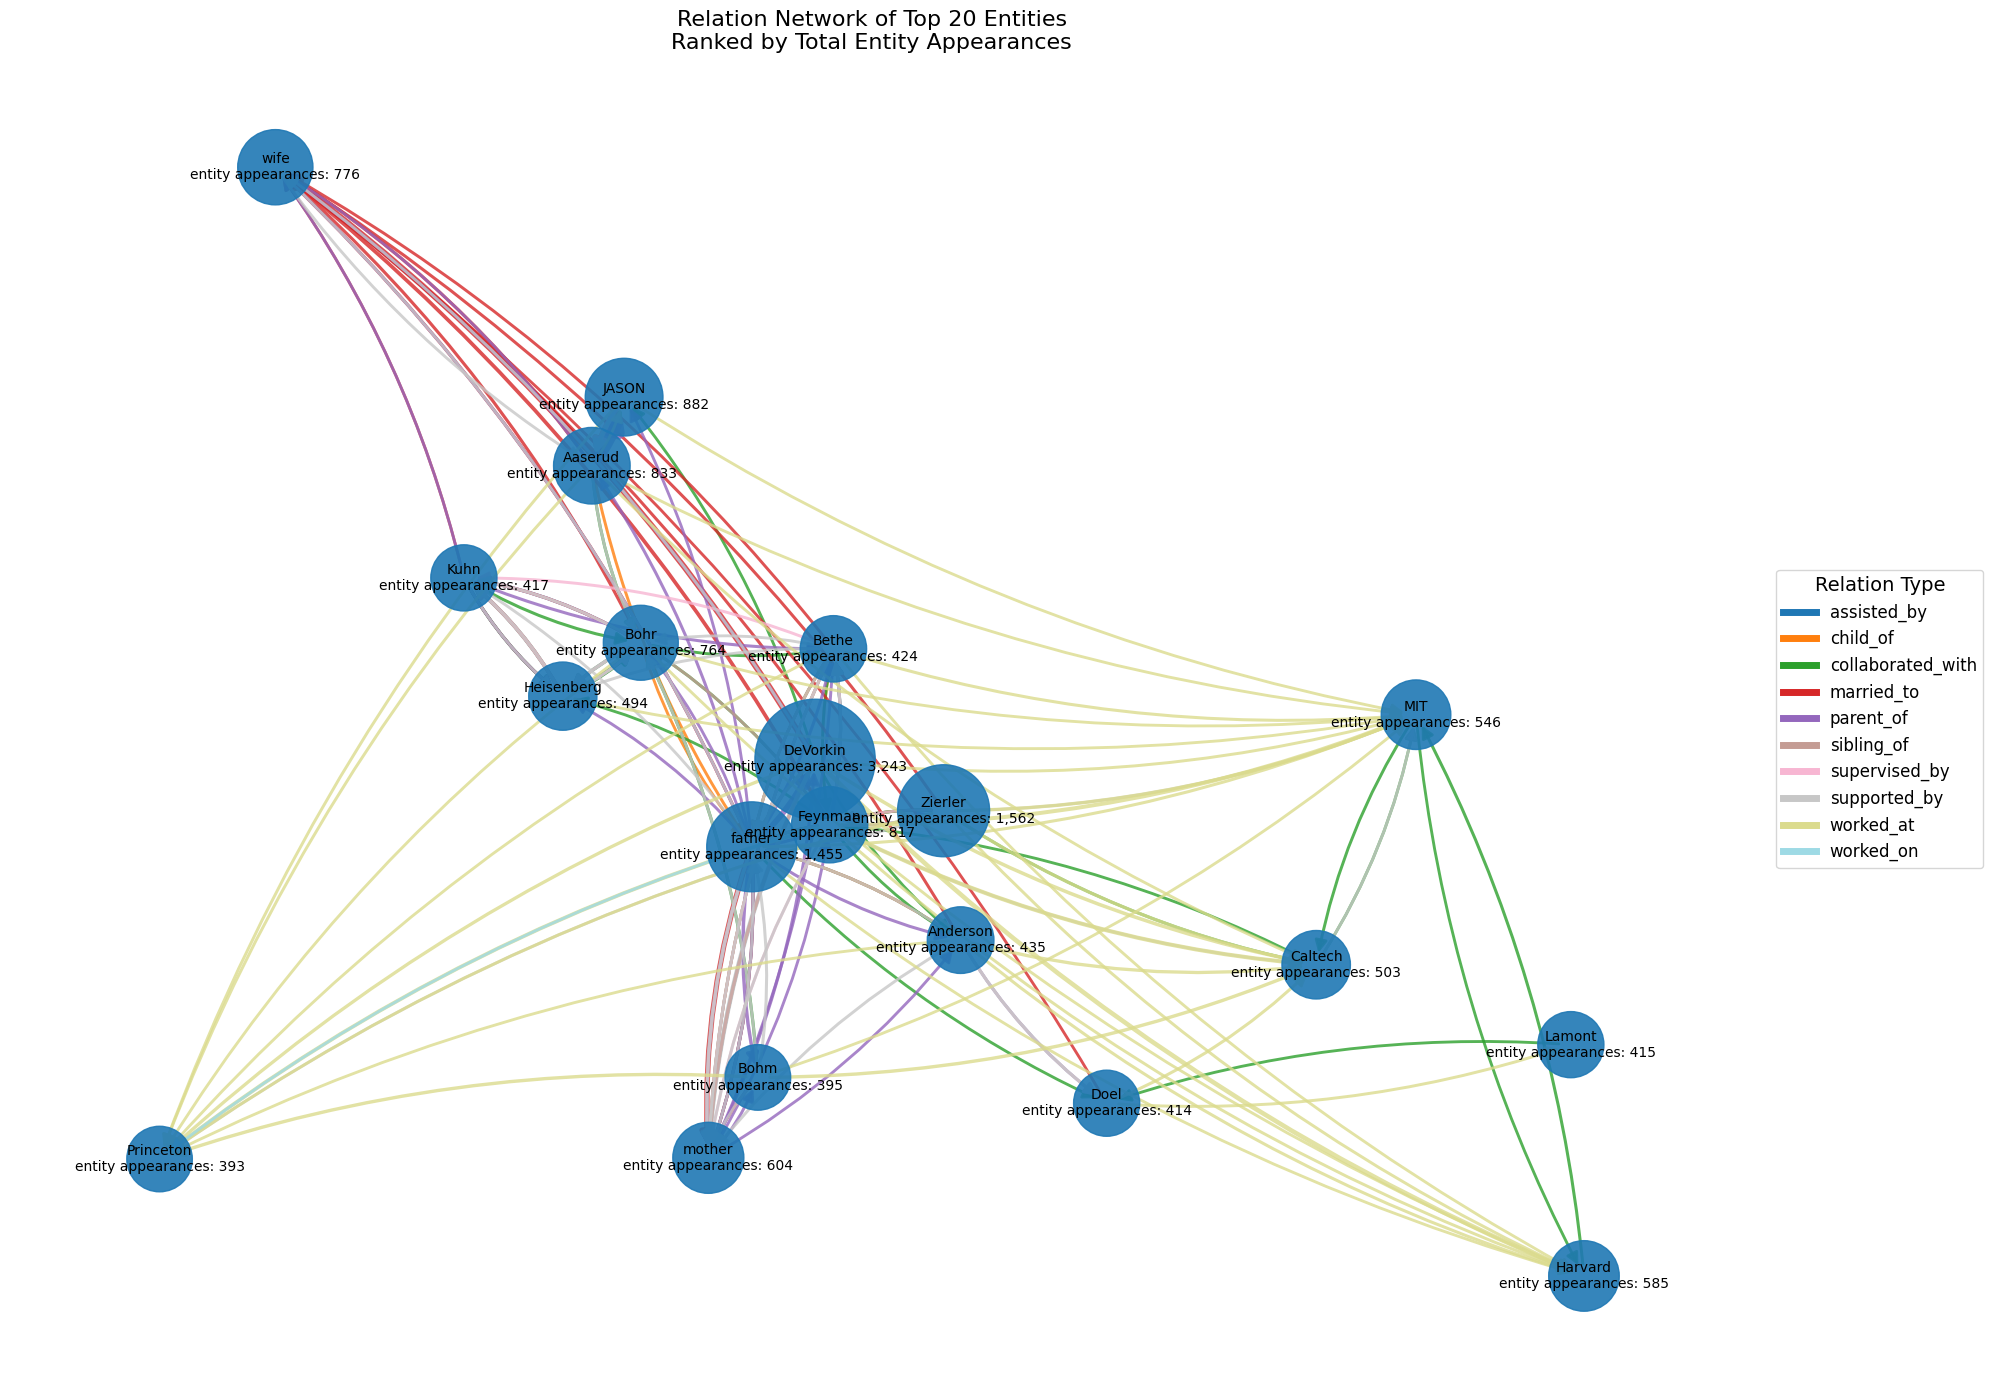


Nodes plotted: 20
Edges plotted: 178
Relation types plotted: 10

Relation types:
- assisted_by: 17 graph edges
- child_of: 11 graph edges
- collaborated_with: 26 graph edges
- married_to: 17 graph edges
- parent_of: 25 graph edges
- sibling_of: 1 graph edges
- supervised_by: 12 graph edges
- supported_by: 33 graph edges
- worked_at: 35 graph edges
- worked_on: 1 graph edges


In [37]:
plt.figure(figsize=(20, 14))

positions = nx.spring_layout(
    graph,
    seed=42,
    k=1.6,
    iterations=100
)


nx.draw_networkx_nodes(
    graph,
    positions,
    node_size=node_sizes,
    alpha=0.9
)


nx.draw_networkx_labels(
    graph,
    positions,
    labels=node_labels,
    font_size=10
)


for relation_type in relation_types:

    relation_edges = [
        (head, tail, key)
        for head, tail, key, data
        in graph.edges(keys=True, data=True)
        if data["relation"] == relation_type
    ]

    relation_widths = [
        2.0 + 7.0 * (
            graph.edges[head, tail, key]["weight"]
            / max_edge_weight
        )
        for head, tail, key in relation_edges
    ]

    relation_edge_pairs = [
        (head, tail)
        for head, tail, _ in relation_edges
    ]

    nx.draw_networkx_edges(
        graph,
        positions,
        edgelist=relation_edge_pairs,
        width=relation_widths,
        edge_color=[relation_colors[relation_type]],
        alpha=0.8,
        arrows=True,
        arrowsize=18,
        connectionstyle="arc3,rad=0.10"
    )


legend_handles = [
    Line2D(
        [0],
        [0],
        color=relation_colors[relation_type],
        linewidth=5,
        label=relation_type
    )
    for relation_type in relation_types
]

plt.legend(
    handles=legend_handles,
    title="Relation Type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=12,
    title_fontsize=14,
    frameon=True
)


ranking_title = (
    "Total Entity Appearances"
    if RANK_BY == "frequency"
    else "Number of Unique Entity Connections"
)

plt.title(
    f"Relation Network of Top {TOP_X} Entities\n"
    f"Ranked by {ranking_title}",
    fontsize=16
)

plt.axis("off")
plt.tight_layout()
plt.show()


print()
print(f"Nodes plotted: {graph.number_of_nodes():,}")
print(f"Edges plotted: {graph.number_of_edges():,}")
print(f"Relation types plotted: {len(relation_types):,}")

print("\nRelation types:")

for relation_type in relation_types:
    relation_edge_count = sum(
        1
        for _, _, data in graph.edges(data=True)
        if data["relation"] == relation_type
    )

    print(
        f"- {relation_type}: "
        f"{relation_edge_count:,} graph edges"
    )